# ORIENT'IA — Métriques du modèle

Ce notebook **ne réentraîne pas** le modèle : il charge le pipeline déjà entraîné et calibré
(`model/orientia_pipeline.joblib`, produit par `orientia_model.ipynb`) et mesure sa qualité de
façon **reproductible et honnête** — à la différence du notebook d'entraînement, qui rapportait
certains chiffres optimistes (poids calibré et évalué sur le même jeu de 149 lignes).

Deux métriques indépendantes :

1. **Classifieur RIASEC → département** (RandomForest, entraîné sur ~26 000 réponses externes
   Kaggle) : validation croisée stratifiée à 5 plis, sur les données d'entraînement externes.
2. **Pipeline complet** (contenu + RIASEC + éligibilité) : taux de réussite top-k sur les 149
   réponses du sondage ISPM réel, avec une **validation croisée imbriquée** pour estimer
   honnêtement la généralisation du choix du poids `w_content` (et pas juste le score sur les
   données ayant servi à le choisir).

Sortie : `model/metrics.json`, à consulter par l'équipe app pour connaître la qualité actuelle du
modèle sans tout ré-exécuter.

In [1]:
import re
import time
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

from orientia_pipeline import OrientiaPipeline

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Chargement des données et du pipeline entraîné

In [2]:
sondage_df = pd.read_csv("data/Sondage.csv")
riasec_raw_df = pd.read_csv("data/riasec.csv", sep=None, engine="python")
pipeline = OrientiaPipeline.load("model/orientia_pipeline.joblib")

print("Sondage ISPM :", sondage_df.shape)
print("RIASEC externe :", riasec_raw_df.shape)
print(f"Pipeline chargé — w_content={pipeline.w_content}, w_riasec={pipeline.w_riasec}, "
      f"{len(pipeline.filieres)} filières, {len(pipeline.dept_order)} départements.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Sondage ISPM : (155, 11)
RIASEC externe : (145828, 94)
Pipeline chargé — w_content=0.4, w_riasec=0.6, 16 filières, 6 départements.


## 2. Reconstruction des jeux de nettoyage

Même logique de nettoyage que `orientia_model.ipynb` (voir ce notebook pour le détail des choix),
reproduite ici uniquement pour pouvoir mesurer les métriques — ce notebook ne modifie ni ne
réentraîne rien.

In [3]:
# --- Sondage ISPM (149 lignes utilisables) ---
RIASEC_MAP = {
    "réaliste": "R", "realiste": "R", "investigateur": "I", "artistique": "A",
    "social": "S", "entreprenant": "E", "conventionnel": "C",
}
riasec_cat_regex = re.compile("|".join(RIASEC_MAP.keys()), re.IGNORECASE)

def parse_riasec_letters(text):
    if not isinstance(text, str):
        return set()
    return {RIASEC_MAP[m.group(0).lower()] for m in riasec_cat_regex.finditer(text)}

DOMAIN_TO_DEPT = {
    "informatique / technologies de l'information et de la communication": "Informatique et Télécommunications",
    "intelligence artificielle": "Informatique et Télécommunications",
    "électronique / systèmes informatiques": "Informatique et Télécommunications",
    "économie et management de projet": "Techniques des Affaires",
    "industrie agroalimentaire": "Biotechnologie et Agronomie",
    "génie civil et architecture": "Génie Civil et Architecture",
    "finances et comptabilité": "Techniques des Affaires",
    "génie industriel / électro-mécanique industrielle": "Génie Industriel",
    "droit et techniques juridiques des affaires": "Techniques des Affaires",
    "industries chimiques, minières et pétrolières": "Génie Industriel",
    "agriculture et élevage": "Biotechnologie et Agronomie",
    "commerce et administration des affaires": "Techniques des Affaires",
    "pharmacologie et industries pharmaceutiques": "Biotechnologie et Agronomie",
    "hôtellerie": "Tourisme",
    "tourisme": "Tourisme",
    "environnement": "Tourisme",
}

def _norm_apostrophes(s):
    return s.replace("’", "'")

DOMAIN_TO_DEPT = {_norm_apostrophes(k): v for k, v in DOMAIN_TO_DEPT.items()}

def map_target_to_departments(raw_text):
    if not isinstance(raw_text, str):
        return set()
    text = _norm_apostrophes(raw_text.lower())
    return {dept for label, dept in DOMAIN_TO_DEPT.items() if label in text}

COL_SERIE = "Quelle était votre série en Terminale ?"
COL_MATIERE = "Quelle a été votre matière préférée au Lycée?"
COL_TARGET = [c for c in sondage_df.columns if c.startswith("Si vous êtes étudiant")][0]
COL_CARACTERE = "Quel(s) Caractère(s) définissent votre personnalité ?"
COL_INTERETS = [c for c in sondage_df.columns if "centres d" in c][0]

clean = sondage_df[[COL_SERIE, COL_MATIERE, COL_TARGET, COL_CARACTERE, COL_INTERETS]].copy()
clean.columns = ["serie", "matiere", "cible_brute", "caractere_brut", "interets"]
clean = clean.dropna(subset=["serie", "matiere", "cible_brute", "caractere_brut"])
clean["riasec_letters"] = clean["caractere_brut"].apply(parse_riasec_letters)
clean["departements_cibles"] = clean["cible_brute"].apply(map_target_to_departments)

eval_rows = clean[clean["departements_cibles"].apply(len) > 0].reset_index(drop=True)
print(f"{len(eval_rows)} lignes du sondage utilisables pour l'évaluation du pipeline complet.")

149 lignes du sondage utilisables pour l'évaluation du pipeline complet.


In [4]:
# --- RIASEC externe (Kaggle) : mêmes règles que l'entraînement ---
riasec_cols = {}
for letter in "RIASEC":
    cols = [c for c in riasec_raw_df.columns if re.fullmatch(rf"{letter}\d+", str(c).strip())]
    riasec_cols[letter] = sorted(cols, key=lambda c: int(re.search(r"\d+", c).group()))

riasec_scores = pd.DataFrame({
    letter: riasec_raw_df[cols].apply(pd.to_numeric, errors="coerce").mean(axis=1)
    for letter, cols in riasec_cols.items()
})

major_col = [c for c in riasec_raw_df.columns if str(c).strip().lower() == "major"][0]

MAJOR_KEYWORDS_TO_DEPT = {
    "Informatique et Télécommunications": [
        "computer", "software", "information technology", r"\bit\b", "informatics",
        "telecommunicat", "electrical engineering", "electronics", "programming",
        "data science", "artificial intelligence", r"\bai\b", "computing",
    ],
    "Génie Industriel": [
        "mechanical engineering", "industrial engineering", "manufacturing",
        "chemical engineering", "mining engineering", "petroleum",
    ],
    "Génie Civil et Architecture": [
        "civil engineering", "architecture", "construction management", "structural engineering",
    ],
    "Techniques des Affaires": [
        "business", "commerce", "management", "finance", "accounting", "economics",
        r"\blaw\b", "marketing", "administration",
    ],
    "Biotechnologie et Agronomie": [
        "biology", "agricultur", "agronomy", "food science", "biotechnology",
        "pharmacy", "pharmacolog", "veterinary", "animal science",
    ],
    "Tourisme": ["tourism", "hospitality", "hotel management"],
}
compiled_keywords = {d: re.compile("|".join(k), re.IGNORECASE) for d, k in MAJOR_KEYWORDS_TO_DEPT.items()}

def major_to_dept(major_text):
    if not isinstance(major_text, str) or not major_text.strip():
        return None
    matches = [d for d, r in compiled_keywords.items() if r.search(major_text)]
    return matches[0] if len(matches) == 1 else None

riasec_scores["departement"] = riasec_raw_df[major_col].apply(major_to_dept)
labelled = riasec_scores.dropna(subset=["departement"]).copy()

MIN_SAMPLES_PER_CLASS = 20
class_counts = labelled["departement"].value_counts()
rare_depts = class_counts[class_counts < MIN_SAMPLES_PER_CLASS].index.tolist()
labelled = labelled[~labelled["departement"].isin(rare_depts)].copy()

print(f"{len(labelled)} lignes RIASEC externes labellisées, {len(rare_depts)} départements rares exclus.")
print(labelled["departement"].value_counts())

26123 lignes RIASEC externes labellisées, 0 départements rares exclus.
departement
Techniques des Affaires               15305
Informatique et Télécommunications     3794
Biotechnologie et Agronomie            3502
Génie Civil et Architecture            1760
Génie Industriel                       1420
Tourisme                                342
Name: count, dtype: int64


## 3. Métrique 1 — Classifieur RIASEC → département

Le notebook d'entraînement rapportait un seul split 80/20 (52.2% d'accuracy). Ici, une
**validation croisée stratifiée à 5 plis** : le classifieur est ré-entraîné à chaque pli avec les
mêmes hyperparamètres, pour vérifier que ce chiffre n'est pas un coup de chance du split.

In [5]:
X = labelled[list("RIASEC")].values
y = labelled["departement"].values

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

fold_acc, fold_f1 = [], []
all_true, all_pred = [], []

t0 = time.time()
for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
    clf = RandomForestClassifier(
        n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
    )
    clf.fit(X[train_idx], y[train_idx])
    pred = clf.predict(X[test_idx])

    fold_acc.append(accuracy_score(y[test_idx], pred))
    fold_f1.append(f1_score(y[test_idx], pred, average="macro"))
    all_true.extend(y[test_idx])
    all_pred.extend(pred)

    print(f"pli {fold}: accuracy={fold_acc[-1]:.3f}  macro-F1={fold_f1[-1]:.3f}")

print(f"\n--> Accuracy moyenne : {np.mean(fold_acc):.3f} (± {np.std(fold_acc):.3f})")
print(f"--> Macro-F1 moyen   : {np.mean(fold_f1):.3f} (± {np.std(fold_f1):.3f})")
print(f"(validation croisée réalisée en {time.time() - t0:.1f}s)")

CLF_CV_ACCURACY_MEAN = float(np.mean(fold_acc))
CLF_CV_ACCURACY_STD = float(np.std(fold_acc))
CLF_CV_MACRO_F1_MEAN = float(np.mean(fold_f1))
CLF_CV_MACRO_F1_STD = float(np.std(fold_f1))

pli 0: accuracy=0.525  macro-F1=0.290


pli 1: accuracy=0.524  macro-F1=0.286


pli 2: accuracy=0.520  macro-F1=0.296


pli 3: accuracy=0.528  macro-F1=0.292


pli 4: accuracy=0.516  macro-F1=0.284

--> Accuracy moyenne : 0.522 (± 0.004)
--> Macro-F1 moyen   : 0.290 (± 0.004)
(validation croisée réalisée en 9.0s)


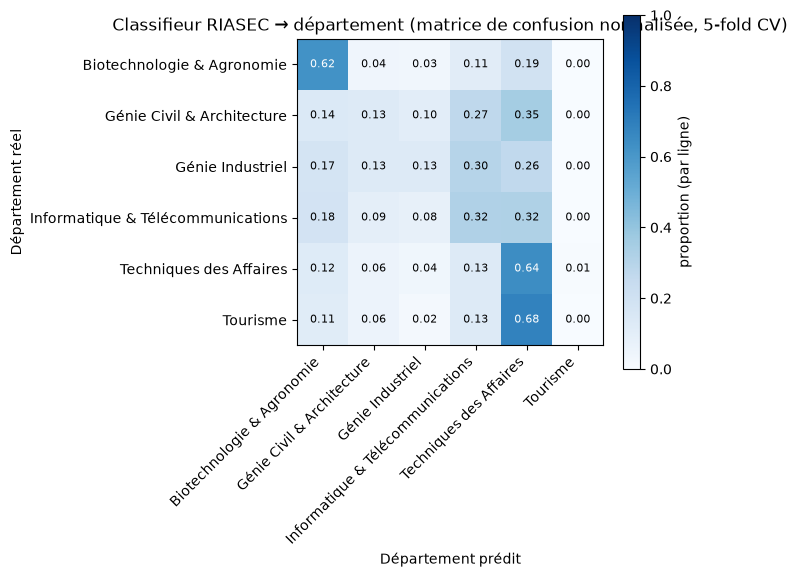

In [6]:
# Matrice de confusion agrégée sur les 5 plis (chaque ligne = vraie classe, chaque colonne = prédiction)
dept_labels = sorted(set(all_true))
cm = confusion_matrix(all_true, all_pred, labels=dept_labels, normalize="true")

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(dept_labels)))
ax.set_yticks(range(len(dept_labels)))
short_labels = [d.replace(" et ", " & ") for d in dept_labels]
ax.set_xticklabels(short_labels, rotation=45, ha="right")
ax.set_yticklabels(short_labels)
ax.set_xlabel("Département prédit")
ax.set_ylabel("Département réel")
ax.set_title("Classifieur RIASEC → département (matrice de confusion normalisée, 5-fold CV)")
for i in range(len(dept_labels)):
    for j in range(len(dept_labels)):
        ax.text(j, i, f"{cm[i, j]:.2f}", ha="center", va="center",
                 color="white" if cm[i, j] > 0.5 else "black", fontsize=8)
fig.colorbar(im, ax=ax, label="proportion (par ligne)")
fig.tight_layout()
fig.savefig("model/confusion_matrix.png", dpi=120)
plt.show()

**Lecture** : le classifieur est fiable sur "Techniques des Affaires" et raisonnable sur
"Biotechnologie et Agronomie" (classes majoritaires), mais confond beaucoup "Génie Industriel" /
"Génie Civil" / "Informatique" entre eux, et ne détecte quasiment jamais "Tourisme" (342 exemples
seulement sur 26 123 — trop peu). Ce n'est pas bloquant pour le pipeline complet : ce score n'est
qu'une des trois composantes combinées avec la similarité de contenu (voir métrique 2), qui
compense en grande partie cette faiblesse.

## 4. Métrique 2 — Pipeline complet sur le sondage ISPM réel

Deux nombres rapportés, pour être transparent sur ce qu'ils mesurent réellement :

- **Score "optimiste"** (identique à celui du notebook d'entraînement) : `w_content` est choisi
  *et* évalué sur les mêmes 149 lignes. C'est le score du pipeline **tel qu'il est livré**
  aujourd'hui (poids figé à `w_content=0.4`).
- **Score "honnête"** (validation croisée imbriquée à 5 plis) : à chaque pli, `w_content` est
  choisi uniquement sur les 4 autres plis, puis évalué sur le pli restant. Ça mesure la
  généralisation de la *procédure de calibration*, pas seulement le résultat sur les données déjà
  vues.

In [7]:
t0 = time.time()
components = [
    pipeline.score_components(row["serie"], row["matiere"], row["interets"], row["riasec_letters"])
    for _, row in eval_rows.iterrows()
]
targets = eval_rows["departements_cibles"].tolist()
filiere_depts = np.array([f["departement"] for f in pipeline.filieres])
print(f"Composantes de score encodées pour {len(components)} profils en {time.time() - t0:.1f}s.")

W_GRID = np.round(np.arange(0.0, 1.01, 0.1), 1)

def hit_rate_at_k(components, targets, w_content, k):
    hits = 0
    for (sim_content_norm, sim_riasec, elig), target_depts in zip(components, targets):
        score = (w_content * sim_content_norm + (1 - w_content) * sim_riasec) * elig
        top_idx = np.argsort(score)[::-1][:k]
        pred_depts = {filiere_depts[i] for i in top_idx}
        if pred_depts & target_depts:
            hits += 1
    return hits / len(components)

Composantes de score encodées pour 149 profils en 15.2s.


In [8]:
# --- Score "optimiste" : poids figé du pipeline livré, évalué sur les 149 lignes ---
w_final = pipeline.w_content
OPTIMISTIC_HIT_RATES = {k: hit_rate_at_k(components, targets, w_final, k) for k in (1, 3, 5)}

print(f"Poids du pipeline livré : w_content={w_final}")
for k, hr in OPTIMISTIC_HIT_RATES.items():
    print(f"  top-{k} hit rate (optimiste, mêmes données) : {hr:.2%}")

Poids du pipeline livré : w_content=0.4
  top-1 hit rate (optimiste, mêmes données) : 56.38%
  top-3 hit rate (optimiste, mêmes données) : 80.54%
  top-5 hit rate (optimiste, mêmes données) : 87.25%


In [9]:
# --- Score "honnête" : validation croisée imbriquée (5 plis) sur le choix de w_content ---
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
idx = np.arange(len(components))

fold_hit3, chosen_ws = [], []
for fold, (train_idx, test_idx) in enumerate(kf.split(idx)):
    train_comp = [components[i] for i in train_idx]
    train_targets = [targets[i] for i in train_idx]
    best_w = max(W_GRID, key=lambda w: hit_rate_at_k(train_comp, train_targets, w, 3))

    test_comp = [components[i] for i in test_idx]
    test_targets = [targets[i] for i in test_idx]
    hr3 = hit_rate_at_k(test_comp, test_targets, best_w, 3)

    fold_hit3.append(hr3)
    chosen_ws.append(float(best_w))
    print(f"pli {fold}: w_content choisi sur les 4 autres plis = {best_w}  ->  top-3 hit rate held-out = {hr3:.2%}")

NESTED_CV_TOP3_MEAN = float(np.mean(fold_hit3))
NESTED_CV_TOP3_STD = float(np.std(fold_hit3))
print(f"\n--> Top-3 hit rate honnête (nested CV) : {NESTED_CV_TOP3_MEAN:.2%} (± {NESTED_CV_TOP3_STD:.2%})")
print(f"    (à comparer au {OPTIMISTIC_HIT_RATES[3]:.2%} optimiste ci-dessus — l'écart mesure le surapprentissage du choix de poids)")
print(f"    poids choisis par pli : {chosen_ws}")

pli 0: w_content choisi sur les 4 autres plis = 0.6  ->  top-3 hit rate held-out = 76.67%
pli 1: w_content choisi sur les 4 autres plis = 0.4  ->  top-3 hit rate held-out = 80.00%
pli 2: w_content choisi sur les 4 autres plis = 0.1  ->  top-3 hit rate held-out = 73.33%
pli 3: w_content choisi sur les 4 autres plis = 0.4  ->  top-3 hit rate held-out = 73.33%
pli 4: w_content choisi sur les 4 autres plis = 0.4  ->  top-3 hit rate held-out = 82.76%

--> Top-3 hit rate honnête (nested CV) : 77.22% (± 3.71%)
    (à comparer au 80.54% optimiste ci-dessus — l'écart mesure le surapprentissage du choix de poids)
    poids choisis par pli : [0.6, 0.4, 0.1, 0.4, 0.4]


## 5. Résumé des métriques

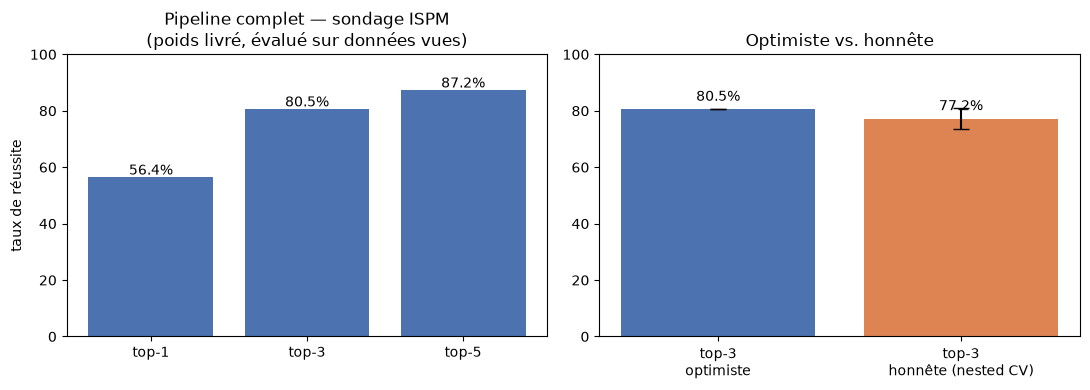

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
ks = list(OPTIMISTIC_HIT_RATES.keys())
vals = [OPTIMISTIC_HIT_RATES[k] * 100 for k in ks]
ax.bar([f"top-{k}" for k in ks], vals, color="#4C72B0")
for i, v in enumerate(vals):
    ax.text(i, v + 1, f"{v:.1f}%", ha="center")
ax.set_ylim(0, 100)
ax.set_ylabel("taux de réussite")
ax.set_title("Pipeline complet — sondage ISPM\n(poids livré, évalué sur données vues)")

ax = axes[1]
labels = ["top-3\noptimiste", "top-3\nhonnête (nested CV)"]
means = [OPTIMISTIC_HIT_RATES[3] * 100, NESTED_CV_TOP3_MEAN * 100]
errs = [0, NESTED_CV_TOP3_STD * 100]
ax.bar(labels, means, yerr=errs, capsize=6, color=["#4C72B0", "#DD8452"])
for i, v in enumerate(means):
    ax.text(i, v + 3, f"{v:.1f}%", ha="center")
ax.set_ylim(0, 100)
ax.set_title("Optimiste vs. honnête")

fig.tight_layout()
fig.savefig("model/metrics_summary.png", dpi=120)
plt.show()

In [11]:
metrics = {
    "generated_at": pd.Timestamp.now().isoformat(),
    "pipeline_weights": {"w_content": pipeline.w_content, "w_riasec": pipeline.w_riasec},
    "riasec_classifier": {
        "method": "5-fold stratified cross-validation",
        "n_samples": int(len(labelled)),
        "accuracy_mean": CLF_CV_ACCURACY_MEAN,
        "accuracy_std": CLF_CV_ACCURACY_STD,
        "macro_f1_mean": CLF_CV_MACRO_F1_MEAN,
        "macro_f1_std": CLF_CV_MACRO_F1_STD,
        "note": "Tourisme quasi jamais détecté (342 exemples / 26123, classe trop rare).",
    },
    "full_pipeline": {
        "n_samples": int(len(eval_rows)),
        "optimistic": {
            "method": "w_content choisi et évalué sur les mêmes 149 lignes (poids livré)",
            "hit_rate_top1": OPTIMISTIC_HIT_RATES[1],
            "hit_rate_top3": OPTIMISTIC_HIT_RATES[3],
            "hit_rate_top5": OPTIMISTIC_HIT_RATES[5],
        },
        "honest_nested_cv": {
            "method": "5-fold KFold, w_content choisi sur les plis d'entraînement uniquement",
            "hit_rate_top3_mean": NESTED_CV_TOP3_MEAN,
            "hit_rate_top3_std": NESTED_CV_TOP3_STD,
            "chosen_w_content_per_fold": chosen_ws,
        },
    },
}

Path("model/metrics.json").write_text(json.dumps(metrics, ensure_ascii=False, indent=2), encoding="utf-8")
print("Métriques sauvegardées dans model/metrics.json :\n")
print(json.dumps(metrics, ensure_ascii=False, indent=2))

Métriques sauvegardées dans model/metrics.json :

{
  "generated_at": "2026-08-27T11:41:48.240220",
  "pipeline_weights": {
    "w_content": 0.4,
    "w_riasec": 0.6
  },
  "riasec_classifier": {
    "method": "5-fold stratified cross-validation",
    "n_samples": 26123,
    "accuracy_mean": 0.522489723543161,
    "accuracy_std": 0.0042949897939603895,
    "macro_f1_mean": 0.28979204054333535,
    "macro_f1_std": 0.0043429626000397745,
    "note": "Tourisme quasi jamais détecté (342 exemples / 26123, classe trop rare)."
  },
  "full_pipeline": {
    "n_samples": 149,
    "optimistic": {
      "method": "w_content choisi et évalué sur les mêmes 149 lignes (poids livré)",
      "hit_rate_top1": 0.5637583892617449,
      "hit_rate_top3": 0.8053691275167785,
      "hit_rate_top5": 0.87248322147651
    },
    "honest_nested_cv": {
      "method": "5-fold KFold, w_content choisi sur les plis d'entraînement uniquement",
      "hit_rate_top3_mean": 0.772183908045977,
      "hit_rate_top3_std":

## Limites connues

- **149 lignes de validation pour le pipeline complet** : c'est peu. La CV imbriquée donne un
  intervalle honnête, mais un écart-type de plusieurs points de pourcentage reste attendu tant que
  le sondage ISPM n'a pas plus de réponses.
- **Classe "Tourisme" mal couverte** partout (peu d'exemples externes *et* peu de lignes sondage) —
  ses recommandations sont surtout portées par la similarité de contenu, pas par le signal RIASEC.
- **`eligibilite_serie` est une heuristique de pondération**, pas une règle d'admission — ne pas
  l'utiliser pour décider qu'un candidat est réellement éligible.
- Ces métriques évaluent la capacité à retrouver le **département déclaré**, pas la filière exacte
  (le sondage ne permet pas de distinguer plusieurs filières d'un même département de façon fiable
  — voir `orientia_model.ipynb`, section 2).